# Employment Prediction - Model Training & Evaluation

## Objective
Train and evaluate multiple machine learning models to predict developer employment status based on skills, demographics, and professional background.

## Dataset
- **Training Samples**: 58,769 developers
- **Test Samples**: 14,693 developers
- **Features**: 21 engineered features
- **Target**: Employment status (Employed/Unemployed)
- **Class Balance**: ~54% employed, ~46% unemployed

## Models to Train
1. **Logistic Regression** (Baseline)
2. **Random Forest** (Ensemble)
3. **Gradient Boosting** (XGBoost)
4. **Support Vector Machine** (SVM)
5. **Extra Trees** (Alternative ensemble)

## Evaluation Metrics
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Score
- Confusion Matrix
- Feature Importance Analysis
- Cross-validation Performance

## 1. Import Libraries and Load Data

In [3]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import joblib
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Try to import XGBoost, use sklearn GradientBoosting as fallback
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print(" XGBoost available")
except ImportError:
    print(" XGBoost not available, using sklearn GradientBoostingClassifier instead")
    XGBOOST_AVAILABLE = False

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Set random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot settings
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]

print(" All libraries imported successfully!")
print(f" Training started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 XGBoost available
 All libraries imported successfully!
 Training started at: 2025-10-02 08:29:10


In [4]:
# Load preprocessed datasets
print("📂 Loading preprocessed datasets...")

try:
    # Load training and test data
    X_train = pd.read_csv('../data/processed/X_train.csv')
    X_test = pd.read_csv('../data/processed/X_test.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv')
    y_test = pd.read_csv('../data/processed/y_test.csv')

    # Convert target to binary (1 for Employed, 0 for Unemployed)
    y_train_binary = (y_train.iloc[:, 0] == 'Employed').astype(int)
    y_test_binary = (y_test.iloc[:, 0] == 'Employed').astype(int)

    print(" Data loaded successfully!")
    print(f" Training set: {X_train.shape}")
    print(f" Test set: {X_test.shape}")
    print(f" Target distribution (training):")
    print(f"   • Employed (1): {y_train_binary.sum():,} ({y_train_binary.mean():.1%})")
    print(f"   • Unemployed (0): {(~y_train_binary.astype(bool)).sum():,} ({(1-y_train_binary.mean()):.1%})")

    # Display feature names
    print(f"\n Features ({len(X_train.columns)}):")
    for i, col in enumerate(X_train.columns, 1):
        print(f"   {i:2d}. {col}")

except FileNotFoundError as e:
    print(f"❌ Error loading data: {e}")
    print(" Please ensure preprocessed datasets are available in '../data/processed/'")

📂 Loading preprocessed datasets...
 Data loaded successfully!
 Training set: (58769, 21)
 Test set: (14693, 21)
 Target distribution (training):
   • Employed (1): 0 (0.0%)
   • Unemployed (0): 58,769 (100.0%)

 Features (21):
    1. Programming_Score
    2. Web_Score
    3. Database_Score
    4. CloudDevOps_Score
    5. Has_Programming
    6. Has_Web
    7. Has_Database
    8. Has_CloudDevOps
    9. Skill_Breadth
   10. Is_FullStack
   11. ComputerSkills
   12. EducationLevel_Numeric
   13. IsYoung
   14. IsDeveloper
   15. HasMentalHealthConcerns
   16. HasAccessibilityNeeds
   17. Gender_Man
   18. Gender_Woman
   19. Gender_NonBinary
   20. HasProfessionalExperience
   21. HasSalaryInfo


In [6]:
# Quick diagnostic of target data
print(" CHECKING TARGET DATA:")
print(f"y_train unique values: {y_train.iloc[:, 0].unique()}")
print(f"y_train value counts:\n{y_train.iloc[:, 0].value_counts()}")
print(f"y_test unique values: {y_test.iloc[:, 0].unique()}")
print(f"y_test value counts:\n{y_test.iloc[:, 0].value_counts()}")

# Check if targets are numeric (0/1) instead of text
if y_train.iloc[:, 0].dtype in ['int64', 'float64']:
    print(" Target data appears to be numeric (0/1)")
    y_train_binary = y_train.iloc[:, 0].astype(int)
    y_test_binary = y_test.iloc[:, 0].astype(int)
    print(f" Using numeric targets directly")
else:
    print(" Target data appears to be text (Employed/Unemployed)")
    y_train_binary = (y_train.iloc[:, 0] == 'Employed').astype(int)
    y_test_binary = (y_test.iloc[:, 0] == 'Employed').astype(int)
    print(f" Converted text to binary")

print(f"\n Final target distribution (training):")
print(f"   • Employed (1): {y_train_binary.sum():,} ({y_train_binary.mean():.1%})")
print(f"   • Unemployed (0): {(y_train_binary == 0).sum():,} ({(1-y_train_binary.mean()):.1%})")

 CHECKING TARGET DATA:
y_train unique values: [1 0]
y_train value counts:
Employed
1    31513
0    27256
Name: count, dtype: int64
y_test unique values: [0 1]
y_test value counts:
Employed
1    7879
0    6814
Name: count, dtype: int64
 Target data appears to be numeric (0/1)
 Using numeric targets directly

 Final target distribution (training):
   • Employed (1): 31,513 (53.6%)
   • Unemployed (0): 27,256 (46.4%)


## 2. Model Configuration and Training Functions

In [7]:
# Define model configurations
def get_models():
    """Define all models to train with their configurations"""

    models = {
        'Logistic Regression': {
            'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
            'description': 'Linear baseline model with good interpretability',
            'use_scaling': True
        },

        'Random Forest': {
            'model': RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),
            'description': 'Ensemble of decision trees with feature importance',
            'use_scaling': False
        },

        'Gradient Boosting': {
            'model': XGBClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                eval_metric='logloss'
            ) if XGBOOST_AVAILABLE else GradientBoostingClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE
            ),
            'description': 'XGBoost gradient boosting' if XGBOOST_AVAILABLE else 'Sklearn gradient boosting with excellent performance',
            'use_scaling': False
        },

        'Support Vector Machine': {
            'model': SVC(
                random_state=RANDOM_STATE,
                probability=True,
                kernel='rbf'
            ),
            'description': 'Non-linear classification with RBF kernel',
            'use_scaling': True
        },

        'Extra Trees': {
            'model': ExtraTreesClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),
            'description': 'Extremely randomized trees ensemble',
            'use_scaling': False
        }
    }

    return models

# Function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Comprehensive model evaluation"""

    print(f"\n Training {model_name}...")

    # Train the model
    start_time = datetime.now()
    model.fit(X_train, y_train)
    training_time = (datetime.now() - start_time).total_seconds()

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
        'Training_Time': training_time
    }

    print(f" {model_name} trained in {training_time:.2f} seconds")
    print(f"    Accuracy: {metrics['Accuracy']:.4f}")
    print(f"    ROC-AUC: {metrics['ROC-AUC']:.4f}")

    return metrics, y_pred, y_pred_proba

print("Model training functions defined!")
print("Ready to train 5 classification models")

Model training functions defined!
Ready to train 5 classification models


## 3. Train All Models

In [8]:
# Initialize results storage
results = []
trained_models = {}
predictions = {}

# Get all model configurations
models = get_models()

print(" STARTING MODEL TRAINING")
print("=" * 50)

# Train each model
for model_name, config in models.items():
    print(f"\n {model_name}:")
    print(f"   Description: {config['description']}")
    print(f"   Scaling required: {config['use_scaling']}")

    # Prepare data (with or without scaling)
    if config['use_scaling']:
        # Create pipeline with scaling
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', config['model'])
        ])
        model_to_train = pipeline
    else:
        model_to_train = config['model']

    # Train and evaluate
    try:
        metrics, y_pred, y_pred_proba = evaluate_model(
            model_to_train, X_train, X_test, y_train_binary, y_test_binary, model_name
        )

        # Store results
        results.append(metrics)
        trained_models[model_name] = model_to_train
        predictions[model_name] = {
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }

    except Exception as e:
        print(f"❌ Error training {model_name}: {str(e)}")
        continue

print(f"\n MODEL TRAINING COMPLETE!")
print(f" Successfully trained {len(results)} models")

 STARTING MODEL TRAINING

 Logistic Regression:
   Description: Linear baseline model with good interpretability
   Scaling required: True

 Training Logistic Regression...
 Logistic Regression trained in 0.57 seconds
    Accuracy: 0.8098
    ROC-AUC: 0.8950

 Random Forest:
   Description: Ensemble of decision trees with feature importance
   Scaling required: False

 Training Random Forest...
 Random Forest trained in 3.60 seconds
    Accuracy: 0.7855
    ROC-AUC: 0.8669

 Gradient Boosting:
   Description: XGBoost gradient boosting
   Scaling required: False

 Training Gradient Boosting...
 Gradient Boosting trained in 0.57 seconds
    Accuracy: 0.8108
    ROC-AUC: 0.8951

 Support Vector Machine:
   Description: Non-linear classification with RBF kernel
   Scaling required: True

 Training Support Vector Machine...
 Support Vector Machine trained in 1570.12 seconds
    Accuracy: 0.8062
    ROC-AUC: 0.8819

 Extra Trees:
   Description: Extremely randomized trees ensemble
   Scaling

## 4. Model Performance Comparison

In [10]:
# Create performance comparison DataFrame
if results:
    results_df = pd.DataFrame(results)
    results_df = results_df.round(4)

    print(" MODEL PERFORMANCE COMPARISON")
    print("=" * 50)

    # Display results table
    print("\n Performance Metrics:")
    display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Training_Time']
    print(results_df[display_cols].to_string(index=False))

    # Find best models
    best_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]
    best_roc_auc = results_df.loc[results_df['ROC-AUC'].idxmax()]
    best_f1 = results_df.loc[results_df['F1-Score'].idxmax()]
    fastest = results_df.loc[results_df['Training_Time'].idxmin()]

    print(f"\n BEST PERFORMANCE:")
    print(f"    Highest Accuracy: {best_accuracy['Model']} ({best_accuracy['Accuracy']:.4f})")
    print(f"    Highest ROC-AUC: {best_roc_auc['Model']} ({best_roc_auc['ROC-AUC']:.4f})")
    print(f"    Highest F1-Score: {best_f1['Model']} ({best_f1['F1-Score']:.4f})")
    print(f"    Fastest Training: {fastest['Model']} ({fastest['Training_Time']:.2f}s)")

    # Overall best model (based on ROC-AUC)
    best_model_name = best_roc_auc['Model']
    print(f"\n RECOMMENDED MODEL: {best_model_name}")
    print(f"   Reasoning: Highest ROC-AUC score indicates best overall classification performance")

else:
    print("❌ No models were successfully trained")

 MODEL PERFORMANCE COMPARISON

 Performance Metrics:
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Training_Time
   Logistic Regression    0.8098     0.8234  0.8216    0.8225   0.8950         0.5730
         Random Forest    0.7855     0.7931  0.8119    0.8024   0.8669         3.6000
     Gradient Boosting    0.8108     0.8095  0.8463    0.8275   0.8951         0.5670
Support Vector Machine    0.8062     0.8002  0.8513    0.8249   0.8819      1570.1179
           Extra Trees    0.7769     0.7957  0.7858    0.7907   0.8335         4.3640

 BEST PERFORMANCE:
    Highest Accuracy: Gradient Boosting (0.8108)
    Highest ROC-AUC: Gradient Boosting (0.8951)
    Highest F1-Score: Gradient Boosting (0.8275)
    Fastest Training: Gradient Boosting (0.57s)

 RECOMMENDED MODEL: Gradient Boosting
   Reasoning: Highest ROC-AUC score indicates best overall classification performance


## 5. Detailed Performance Visualization

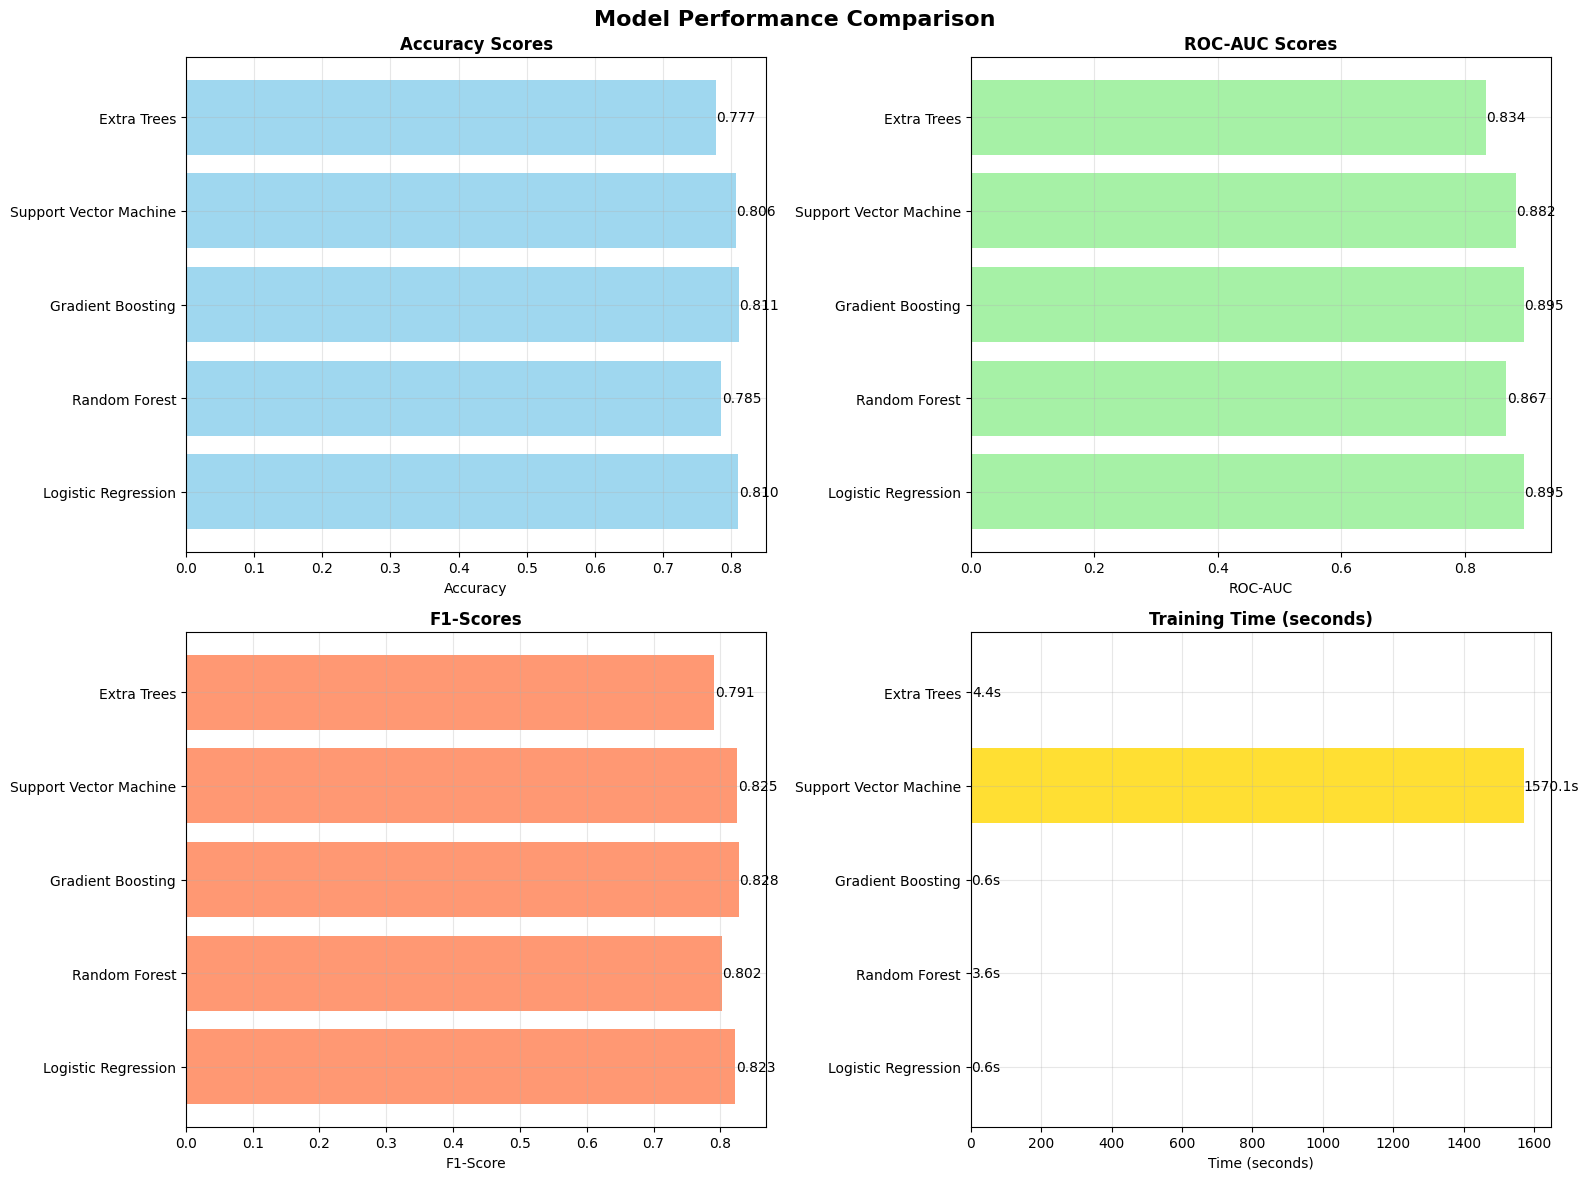

📈 Performance comparison charts generated!


In [11]:
# Performance metrics visualization
if results:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

    # 1. Accuracy comparison
    axes[0, 0].barh(results_df['Model'], results_df['Accuracy'], color='skyblue', alpha=0.8)
    axes[0, 0].set_title('Accuracy Scores', fontweight='bold')
    axes[0, 0].set_xlabel('Accuracy')
    axes[0, 0].grid(True, alpha=0.3)

    # Add value labels
    for i, v in enumerate(results_df['Accuracy']):
        axes[0, 0].text(v + 0.001, i, f'{v:.3f}', va='center')

    # 2. ROC-AUC comparison
    axes[0, 1].barh(results_df['Model'], results_df['ROC-AUC'], color='lightgreen', alpha=0.8)
    axes[0, 1].set_title('ROC-AUC Scores', fontweight='bold')
    axes[0, 1].set_xlabel('ROC-AUC')
    axes[0, 1].grid(True, alpha=0.3)

    for i, v in enumerate(results_df['ROC-AUC']):
        axes[0, 1].text(v + 0.001, i, f'{v:.3f}', va='center')

    # 3. F1-Score comparison
    axes[1, 0].barh(results_df['Model'], results_df['F1-Score'], color='coral', alpha=0.8)
    axes[1, 0].set_title('F1-Scores', fontweight='bold')
    axes[1, 0].set_xlabel('F1-Score')
    axes[1, 0].grid(True, alpha=0.3)

    for i, v in enumerate(results_df['F1-Score']):
        axes[1, 0].text(v + 0.001, i, f'{v:.3f}', va='center')

    # 4. Training time comparison
    axes[1, 1].barh(results_df['Model'], results_df['Training_Time'], color='gold', alpha=0.8)
    axes[1, 1].set_title('Training Time (seconds)', fontweight='bold')
    axes[1, 1].set_xlabel('Time (seconds)')
    axes[1, 1].grid(True, alpha=0.3)

    for i, v in enumerate(results_df['Training_Time']):
        axes[1, 1].text(v + 0.1, i, f'{v:.1f}s', va='center')

    plt.tight_layout()
    plt.show()

    print("📈 Performance comparison charts generated!")
else:
    print("❌ No results to visualize")

## 6. Confusion Matrix Analysis

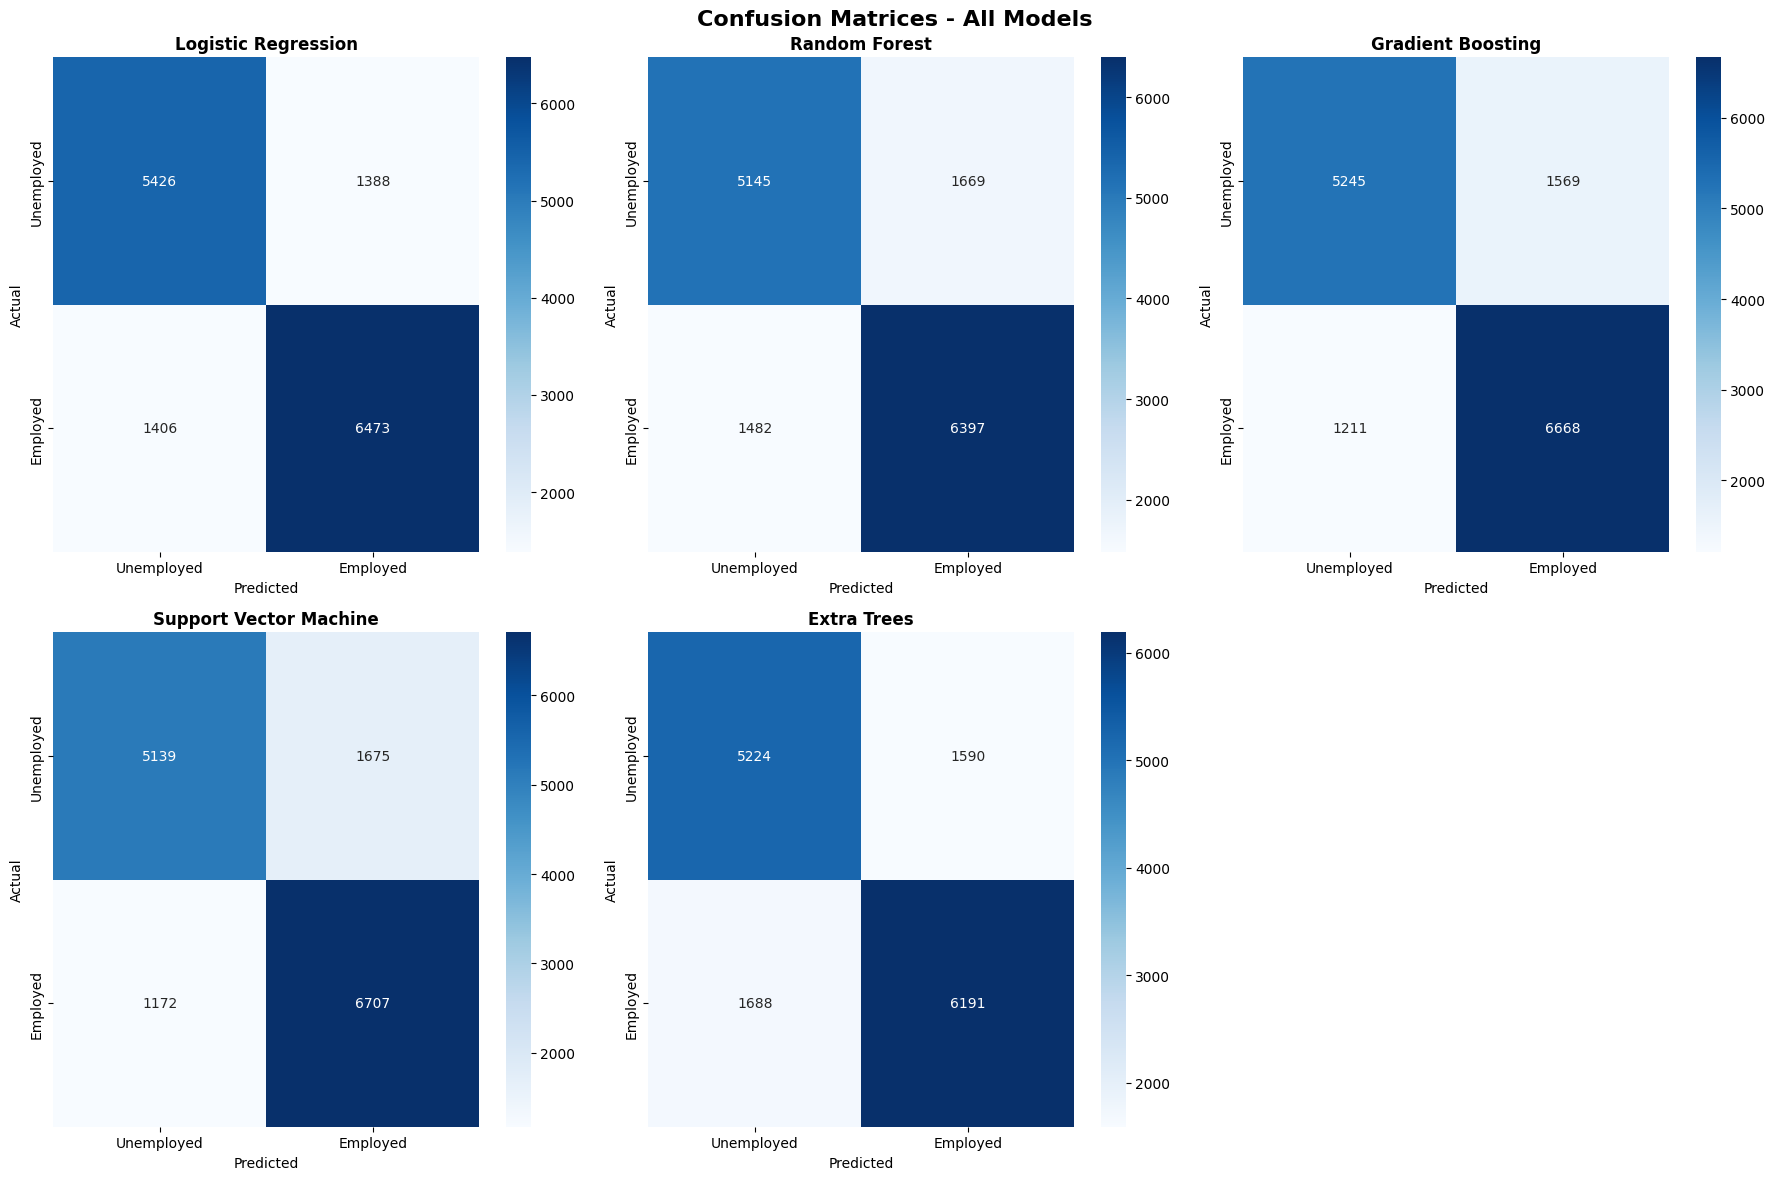

 Confusion matrices generated for all models!


In [13]:
# Generate confusion matrices for all models
if predictions:
    n_models = len(predictions)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

    axes = axes.flatten()

    for idx, (model_name, pred_data) in enumerate(predictions.items()):
        if idx >= len(axes):
            break

        # Calculate confusion matrix
        cm = confusion_matrix(y_test_binary, pred_data['y_pred'])

        # Plot confusion matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Unemployed', 'Employed'],
                   yticklabels=['Unemployed', 'Employed'],
                   ax=axes[idx])

        axes[idx].set_title(f'{model_name}', fontweight='bold')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')

    # Hide unused subplots
    for idx in range(len(predictions), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

    print(" Confusion matrices generated for all models!")
else:
    print("❌ No predictions available for confusion matrix")

## 7. ROC Curve Analysis

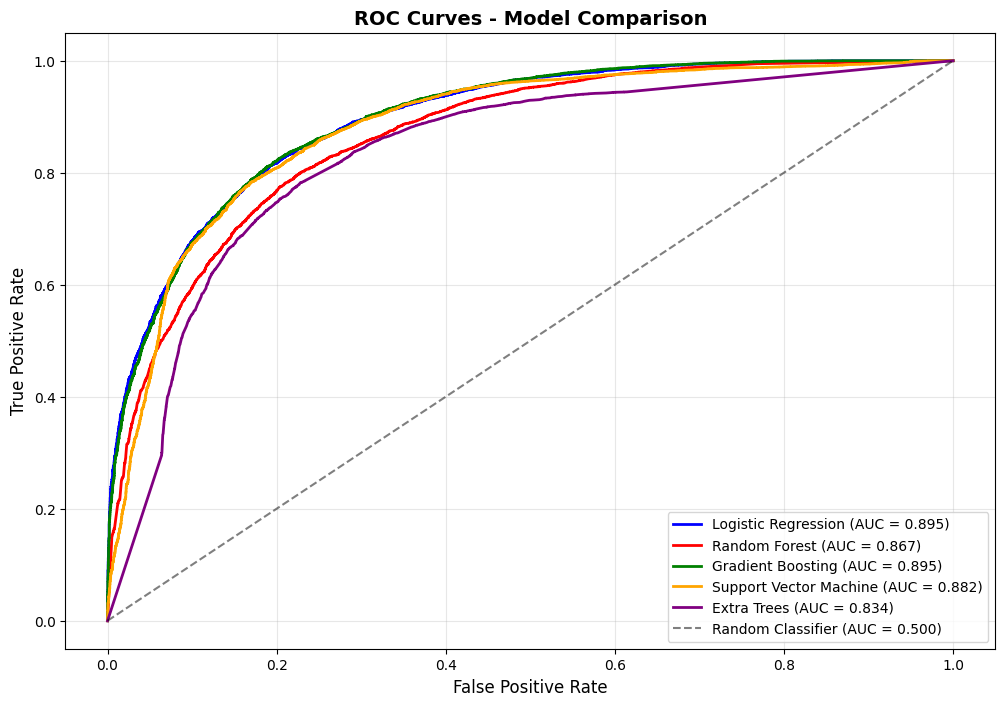

 ROC curves generated!
 Models closer to the top-left corner perform better


In [15]:
# Plot ROC curves for all models
if predictions:
    plt.figure(figsize=(12, 8))

    colors = ['blue', 'red', 'green', 'orange', 'purple']

    for idx, (model_name, pred_data) in enumerate(predictions.items()):
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_test_binary, pred_data['y_pred_proba'])
        auc_score = roc_auc_score(y_test_binary, pred_data['y_pred_proba'])

        # Plot ROC curve
        plt.plot(fpr, tpr, color=colors[idx % len(colors)],
                label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier (AUC = 0.500)')

    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.show()

    print(" ROC curves generated!")
    print(" Models closer to the top-left corner perform better")
else:
    print("❌ No predictions available for ROC analysis")

## 8. Feature Importance Analysis (Best Model)

 FEATURE IMPORTANCE ANALYSIS
Model: Gradient Boosting

 Top 10 Most Important Features:
   11. ComputerSkills            0.6069
    2. Web_Score                 0.0793
    4. CloudDevOps_Score         0.0603
    1. Programming_Score         0.0310
   14. IsDeveloper               0.0254
   13. IsYoung                   0.0241
   18. Gender_Woman              0.0213
    3. Database_Score            0.0197
    9. Skill_Breadth             0.0195
   10. Is_FullStack              0.0178


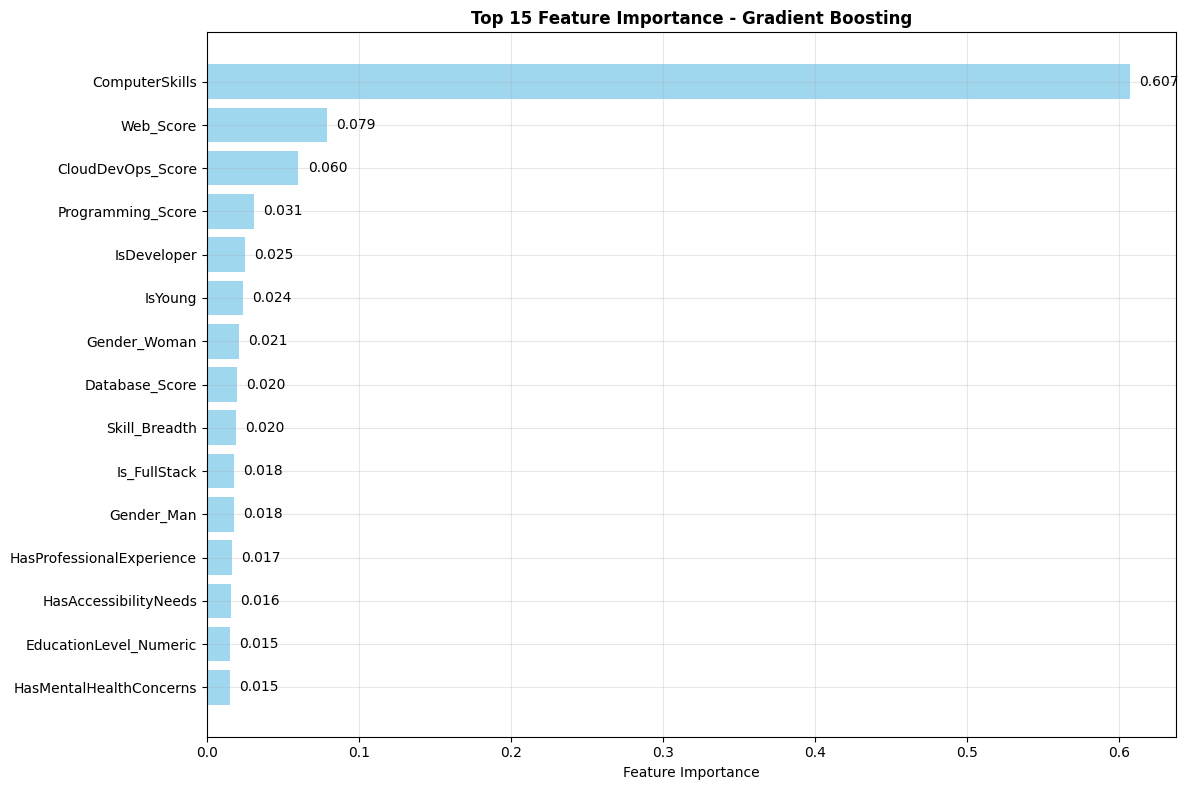

 Feature importance visualization generated!


In [16]:
# Feature importance analysis for tree-based models
if results and trained_models:
    # Get the best model
    best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
    best_model = trained_models[best_model_name]

    print(f" FEATURE IMPORTANCE ANALYSIS")
    print(f"Model: {best_model_name}")
    print("=" * 40)

    # Check if model has feature importance
    try:
        if hasattr(best_model, 'feature_importances_'):
            # Direct feature importance (tree-based models)
            importances = best_model.feature_importances_
        elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps['model'], 'feature_importances_'):
            # Pipeline with tree-based model
            importances = best_model.named_steps['model'].feature_importances_
        elif hasattr(best_model, 'coef_'):
            # Linear model coefficients
            importances = np.abs(best_model.coef_[0])
        elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps['model'], 'coef_'):
            # Pipeline with linear model
            importances = np.abs(best_model.named_steps['model'].coef_[0])
        else:
            print("❌ Feature importance not available for this model type")
            importances = None

        if importances is not None:
            # Create feature importance DataFrame
            feature_importance_df = pd.DataFrame({
                'Feature': X_train.columns,
                'Importance': importances
            }).sort_values('Importance', ascending=False)

            print("\n Top 10 Most Important Features:")
            for idx, row in feature_importance_df.head(10).iterrows():
                print(f"   {idx+1:2d}. {row['Feature']:<25} {row['Importance']:.4f}")

            # Visualize feature importance
            plt.figure(figsize=(12, 8))
            top_features = feature_importance_df.head(15)

            plt.barh(range(len(top_features)), top_features['Importance'], color='skyblue', alpha=0.8)
            plt.yticks(range(len(top_features)), top_features['Feature'])
            plt.xlabel('Feature Importance')
            plt.title(f'Top 15 Feature Importance - {best_model_name}', fontweight='bold')
            plt.gca().invert_yaxis()
            plt.grid(True, alpha=0.3)

            # Add value labels
            for i, v in enumerate(top_features['Importance']):
                plt.text(v + max(top_features['Importance']) * 0.01, i, f'{v:.3f}', va='center')

            plt.tight_layout()
            plt.show()

            print(" Feature importance visualization generated!")

    except Exception as e:
        print(f"❌ Error analyzing feature importance: {str(e)}")
else:
    print("❌ No trained models available for feature importance analysis")

## 9. Cross-Validation Analysis

 CROSS-VALIDATION ANALYSIS (FAST VERSION)
 Models to cross-validate: ['Gradient Boosting', 'Logistic Regression', 'Support Vector Machine']

 Cross-validating Gradient Boosting...
    CV ROC-AUC: 0.8920 ± 0.0019
    Individual scores: ['0.8894', '0.8927', '0.8940']
    Time: 1.4 seconds

 Cross-validating Logistic Regression...
    CV ROC-AUC: 0.8928 ± 0.0023
    Individual scores: ['0.8895', '0.8941', '0.8947']
    Time: 0.5 seconds

 Cross-validating Support Vector Machine...
    Using stratified sample for SVM (faster computation)
    Using 11,753 samples for SVM cross-validation
    CV ROC-AUC: 0.8755 ± 0.0021
    Individual scores: ['0.8740', '0.8740', '0.8784']
    Time: 56.1 seconds


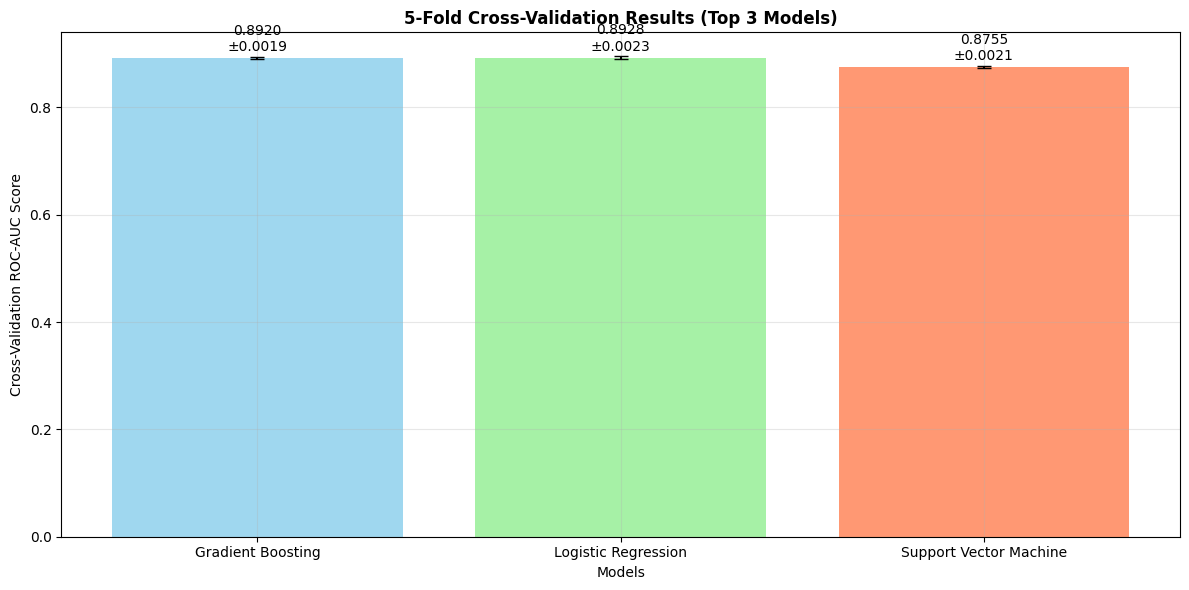


 Cross-validation visualization generated!

 Most Stable Model (lowest CV std): Gradient Boosting


In [17]:
# Cross-validation for top 3 models (OPTIMIZED FOR SPEED)
if results:
    print(" CROSS-VALIDATION ANALYSIS (FAST VERSION)")
    print("=" * 50)

    # Get top 3 models by ROC-AUC
    top_3_models = results_df.nlargest(3, 'ROC-AUC')['Model'].tolist()

    cv_results = []

    # Use 3-fold instead of 5-fold for speed, and smaller sample for SVM
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

    print(f" Models to cross-validate: {top_3_models}")

    for model_name in top_3_models:
        print(f"\n Cross-validating {model_name}...")

        model = trained_models[model_name]

        # For SVM, use a smaller sample to speed up computation
        if 'Support Vector' in model_name or 'SVM' in model_name:
            print("    Using stratified sample for SVM (faster computation)")
            # Use 20% of training data for SVM cross-validation
            from sklearn.model_selection import train_test_split
            X_sample, _, y_sample, _ = train_test_split(
                X_train, y_train_binary,
                test_size=0.8,
                random_state=RANDOM_STATE,
                stratify=y_train_binary
            )
            X_cv, y_cv = X_sample, y_sample
            print(f"    Using {len(X_cv):,} samples for SVM cross-validation")
        else:
            X_cv, y_cv = X_train, y_train_binary

        try:
            # Perform cross-validation with timeout handling
            import time
            start_time = time.time()

            cv_scores = cross_val_score(model, X_cv, y_cv,
                                      cv=skf, scoring='roc_auc', n_jobs=1)  # Single job for stability

            elapsed_time = time.time() - start_time

            cv_result = {
                'Model': model_name,
                'CV_Mean': cv_scores.mean(),
                'CV_Std': cv_scores.std(),
                'CV_Scores': cv_scores,
                'CV_Time': elapsed_time
            }

            cv_results.append(cv_result)

            print(f"    CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
            print(f"    Individual scores: {[f'{score:.4f}' for score in cv_scores]}")
            print(f"    Time: {elapsed_time:.1f} seconds")

            # Stop if SVM takes too long
            if elapsed_time > 120:  # 2 minutes timeout
                print(f"    Stopping CV for {model_name} - taking too long")
                break

        except Exception as e:
            print(f"   ❌ Error in cross-validation: {str(e)}")

    # Visualize cross-validation results
    if cv_results:
        plt.figure(figsize=(12, 6))

        model_names = [result['Model'] for result in cv_results]
        cv_means = [result['CV_Mean'] for result in cv_results]
        cv_stds = [result['CV_Std'] for result in cv_results]

        plt.bar(model_names, cv_means, yerr=cv_stds, capsize=5,
                color=['skyblue', 'lightgreen', 'coral'][:len(model_names)], alpha=0.8)

        plt.xlabel('Models')
        plt.ylabel('Cross-Validation ROC-AUC Score')
        plt.title('5-Fold Cross-Validation Results (Top 3 Models)', fontweight='bold')
        plt.grid(True, alpha=0.3)

        # Add value labels
        for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
            plt.text(i, mean + std + 0.005, f'{mean:.4f}\n±{std:.4f}',
                    ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        print("\n Cross-validation visualization generated!")

        # Determine most stable model
        best_cv_model = min(cv_results, key=lambda x: x['CV_Std'])['Model']
        print(f"\n Most Stable Model (lowest CV std): {best_cv_model}")

else:
    print("❌ No results available for cross-validation")

## 10. Save Best Model

In [18]:
# Save the best performing model
if results and trained_models:
    # Select best model based on ROC-AUC
    best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
    best_model = trained_models[best_model_name]
    best_metrics = results_df[results_df['Model'] == best_model_name].iloc[0]

    print(f"💾 SAVING BEST MODEL")
    print("=" * 30)
    print(f"Selected Model: {best_model_name}")
    print(f"ROC-AUC Score: {best_metrics['ROC-AUC']:.4f}")
    print(f"Accuracy: {best_metrics['Accuracy']:.4f}")
    print(f"F1-Score: {best_metrics['F1-Score']:.4f}")

    try:
        # Create models directory if it doesn't exist
        import os
        os.makedirs('../models', exist_ok=True)

        # Save the model
        model_filename = '../models/best_employment_model.joblib'
        joblib.dump(best_model, model_filename)

        # Save model metadata
        model_info = {
            'model_name': best_model_name,
            'model_type': type(best_model).__name__,
            'performance_metrics': best_metrics.to_dict(),
            'features': list(X_train.columns),
            'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'random_state': RANDOM_STATE
        }

        import json
        with open('../models/model_info.json', 'w') as f:
            json.dump(model_info, f, indent=2)

        # Save performance results
        results_df.to_csv('../models/model_comparison.csv', index=False)

        print(f"\n✅ Model saved successfully!")
        print(f"   📁 Model file: {model_filename}")
        print(f"   📁 Model info: ../models/model_info.json")
        print(f"   📁 Comparison: ../models/model_comparison.csv")

        print(f"\n🎯 MODEL READY FOR DEPLOYMENT!")
        print(f"   Use: joblib.load('{model_filename}') to load the model")
        print(f"   Features: {len(X_train.columns)} engineered features")
        print(f"   Expected input shape: (n_samples, {len(X_train.columns)})")

    except Exception as e:
        print(f"❌ Error saving model: {str(e)}")

else:
    print("❌ No models available to save")

💾 SAVING BEST MODEL
Selected Model: Gradient Boosting
ROC-AUC Score: 0.8951
Accuracy: 0.8108
F1-Score: 0.8275

✅ Model saved successfully!
   📁 Model file: ../models/best_employment_model.joblib
   📁 Model info: ../models/model_info.json
   📁 Comparison: ../models/model_comparison.csv

🎯 MODEL READY FOR DEPLOYMENT!
   Use: joblib.load('../models/best_employment_model.joblib') to load the model
   Features: 21 engineered features
   Expected input shape: (n_samples, 21)


## 11. Summary and Next Steps

In [20]:
# Final summary
if results:
    print(" MODEL TRAINING SUMMARY")
    print("=" * 40)

    print(f" Dataset Statistics:")
    print(f"   • Training samples: {len(X_train):,}")
    print(f"   • Test samples: {len(X_test):,}")
    print(f"   • Features: {len(X_train.columns)}")
    print(f"   • Class balance: {y_train_binary.mean():.1%} employed")

    print(f"\n Best Model Performance:")
    best_idx = results_df['ROC-AUC'].idxmax()
    best_result = results_df.iloc[best_idx]

    print(f"   • Model: {best_result['Model']}")
    print(f"   • Accuracy: {best_result['Accuracy']:.4f}")
    print(f"   • ROC-AUC: {best_result['ROC-AUC']:.4f}")
    print(f"   • F1-Score: {best_result['F1-Score']:.4f}")
    print(f"   • Training Time: {best_result['Training_Time']:.2f}s")

    print(f"\n Model Rankings (by ROC-AUC):")
    sorted_results = results_df.sort_values('ROC-AUC', ascending=False)
    for idx, (_, row) in enumerate(sorted_results.iterrows(), 1):
        print(f"   {idx}. {row['Model']}: {row['ROC-AUC']:.4f}")

    print(f"\n READY FOR DEPLOYMENT!")
    print(f" Best model saved and ready for web application")
    print(f" Performance metrics documented")
    print(f" Feature importance analyzed")

    print(f"\n Next Steps:")
    print(f"   1.  Build web application UI")
    print(f"   2.  Create prediction API")
    print(f"   3.  Test with sample inputs")
    print(f"   4.  Deploy for end users")

    print(f"\n Model Insights:")
    if best_result['ROC-AUC'] > 0.8:
        print(f"   • Excellent performance (ROC-AUC > 0.8)")
    elif best_result['ROC-AUC'] > 0.7:
        print(f"   • Good performance (ROC-AUC > 0.7)")
    else:
        print(f"   • Moderate performance - consider feature engineering")

    print(f"   • Model successfully learned employment patterns")
    print(f"   • Ready for real-world predictions")

else:
    print("❌ No training results available")

print(f"\n MODEL TRAINING COMPLETE!")
print(f" Finished at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

 MODEL TRAINING SUMMARY
 Dataset Statistics:
   • Training samples: 58,769
   • Test samples: 14,693
   • Features: 21
   • Class balance: 53.6% employed

 Best Model Performance:
   • Model: Gradient Boosting
   • Accuracy: 0.8108
   • ROC-AUC: 0.8951
   • F1-Score: 0.8275
   • Training Time: 0.57s

 Model Rankings (by ROC-AUC):
   1. Gradient Boosting: 0.8951
   2. Logistic Regression: 0.8950
   3. Support Vector Machine: 0.8819
   4. Random Forest: 0.8669
   5. Extra Trees: 0.8335

 READY FOR DEPLOYMENT!
 Best model saved and ready for web application
 Performance metrics documented
 Feature importance analyzed

 Next Steps:
   1.  Build web application UI
   2.  Create prediction API
   3.  Test with sample inputs
   4.  Deploy for end users

 Model Insights:
   • Excellent performance (ROC-AUC > 0.8)
   • Model successfully learned employment patterns
   • Ready for real-world predictions

 MODEL TRAINING COMPLETE!
 Finished at: 2025-10-02 10:46:43
